# Flatten a Plot3D mesh into a finite-volume graph

This tutorial builds a **finite-volume graph** from a Plot3D multi-block
mesh: cells become graph nodes, and the faces between them become directed
`owner -> neighbor` edges carrying real geometry. That graph -- built by
`plot3d.flatmesh.flatten_mesh` -- is what a GPU CFD solver actually reads
and starts solving with.

Six short sections, in order:

1. **Connectivity, visually** -- what "flattening" means, before any code.
2. **Simple block** -- flatten one block, no connectivity or boundary
   conditions needed, and check every field by hand.
3. **The production duct mesh** -- the same duct, at solve resolution:
   its geometry, its 3D mesh, its flattened 2D mesh, then split into two
   real blocks so `flatten_mesh` has an actual cross-block interface to
   weld, on top of the self-seam a full 360 degree revolve creates
   against itself.
4. **Exporting to simulation** -- tag the boundaries, see where every
   boundary condition actually lands at the node level, and write what a
   solver reads.
5. **Solving it** -- the same duct, with a JAX axisymmetric Euler solver
   run on the flattened mesh.
6. **Why flatten?** -- the same duct solved three ways (a plain Plot3D
   block with nested loops, the flattened mesh on JAX, the flattened mesh
   forced onto CPU), timed live.

This notebook does **not** cover the `lb`/`ub` diagonal convention or the
8-permutation cross-plane system -- that's its own short notebook,
[`Plot3D_CrossPlaneConnectivity.ipynb`](Plot3D_CrossPlaneConnectivity.ipynb),
if you want the mechanics of how a face match is recorded. Nothing here
depends on it.


## Install

Clones the repo and installs `plot3d` (editable) plus the `examples` extra
(`pyturbo-aero` + `jax`). Sections 2 and 5 both use the converging-diverging
duct example that lives in the repo itself, not on PyPI:


In [1]:
!pip install -U plot3d


In [6]:
!test -d Plot3D_utilities || git clone --depth 1 https://github.com/nasa/Plot3D_utilities.git
%cd Plot3D_utilities
%pip install -q -e ".[examples]"
%cd ..

import sys
sys.path.insert(0, "Plot3D_utilities/examples/converge_diverge_duct")


/content/Plot3D_utilities
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for plot3d (pyproject.toml) ... done
/content


In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D

from plot3d import Block, flatten_mesh, cell_volume_divergence
from plot3d.connectivity import connectivity
from plot3d.glennht import (
    tag_surfaces_geometric,
    write_boundary_conditions_yaml,
    Plot3DFlattenInletBC,
    Plot3DFlattenOutletBC,
    Plot3DFlattenWallBC,
)

OUT_DIR = "flatten_out"
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Connectivity, visually

A Plot3D mesh is a set of **blocks**, each a structured `(i, j, k)` grid of
nodes. Every node connects to its `i-1`/`i+1`, `j-1`/`j+1`, `k-1`/`k+1`
neighbors *within* its own block -- that part's simple. The interesting
part is *between* blocks: two blocks "connect" when one block's face sits
at the exact same physical location as another block's face.

That's the whole idea behind flattening. Below, two tiny blocks (8 nodes
each, just their corners) sit side by side. The orange nodes are one
block's face and the other block's face -- two *different* sets of nodes
that happen to sit at the same physical points. Flattening **welds** them
into one shared graph node, exactly like the dashed lines suggest:


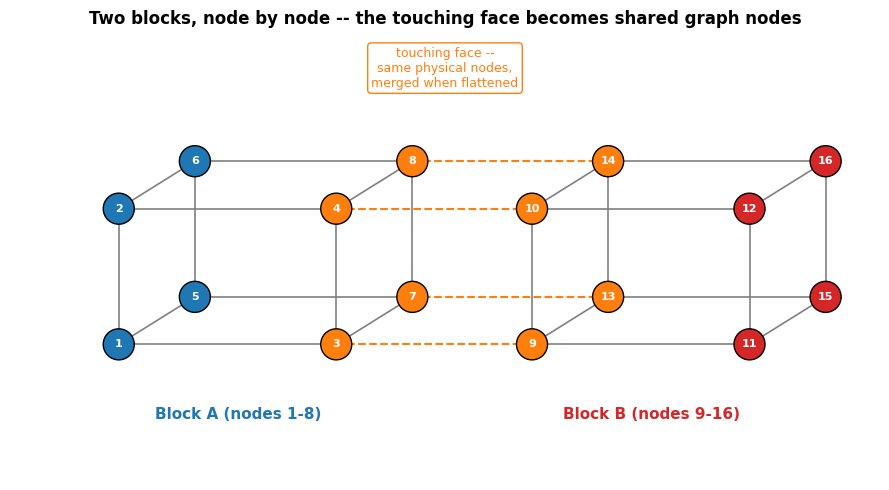

In [3]:
def cube_graph(base_id, x_origin, color):
    """8 corner nodes of a unit cube, id = base_id + 4*i + 2*j + k + 1,
    laid out with a slight (i-axis) skew so the cube reads as 3D on a flat
    2D plot. Returns the graph, its node positions, and the two node id
    lists for the j=0 and j=1 faces (the ones that can touch a neighbor)."""
    G = nx.Graph()
    pos, ids = {}, {}
    for i in (0, 1):
        for j in (0, 1):
            for k in (0, 1):
                nid = base_id + 4 * i + 2 * j + k + 1
                ids[(i, j, k)] = nid
                pos[nid] = (x_origin + j + 0.35 * i, k + 0.35 * i)
                G.add_node(nid)
    for i in (0, 1):
        for j in (0, 1):
            for k in (0, 1):
                for di, dj, dk in [(1, 0, 0), (0, 1, 0), (0, 0, 1)]:
                    ii, jj, kk = i + di, j + dj, k + dk
                    if ii <= 1 and jj <= 1 and kk <= 1:
                        G.add_edge(ids[(i, j, k)], ids[(ii, jj, kk)])
    face_j0 = [ids[(i, 0, k)] for i in (0, 1) for k in (0, 1)]
    face_j1 = [ids[(i, 1, k)] for i in (0, 1) for k in (0, 1)]
    return G, pos, face_j0, face_j1


GA, posA, A_j0, A_j1 = cube_graph(base_id=0, x_origin=0.0, color="tab:blue")
GB, posB, B_j0, B_j1 = cube_graph(base_id=8, x_origin=1.9, color="tab:red")
G = nx.compose(GA, GB)
pos = {**posA, **posB}

touching = set(A_j1) | set(B_j0)
node_colors = ["tab:orange" if n in touching else ("tab:blue" if n <= 8 else "tab:red") for n in G.nodes]

fig, ax = plt.subplots(figsize=(9, 5))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", width=1.2)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=500,
                       edgecolors="black", linewidths=1.0)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white", font_weight="bold")

# weld lines: block A's j=1 face node <-> the matching block B j=0 face
# node (matched by (i, k), i.e. "the corner in the same spot")
for a, b in zip(A_j1, B_j0):
    xa, ya = pos[a]
    xb, yb = pos[b]
    ax.plot([xa, xb], [ya, yb], linestyle="--", color="tab:orange", linewidth=1.5, zorder=0)

ax.text(0.55, -0.55, "Block A (nodes 1-8)", ha="center", fontsize=11, fontweight="bold", color="tab:blue")
ax.text(2.45, -0.55, "Block B (nodes 9-16)", ha="center", fontsize=11, fontweight="bold", color="tab:red")
ax.text(1.5, 1.9, "touching face --\nsame physical nodes,\nmerged when flattened",
        ha="center", fontsize=9, color="tab:orange",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="tab:orange"))
ax.set_title("Two blocks, node by node -- the touching face becomes shared graph nodes",
             fontsize=12, fontweight="bold")
ax.axis("off")
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-1.0, 2.3)
plt.tight_layout()
plt.show()


That's it -- that's flattening. `plot3d.connectivity.connectivity()` finds
*which* faces touch (comparing every block's exterior faces against every
other block's, and its own). `plot3d.flatmesh.flatten_mesh` does the
welding above for real, across an entire mesh, and turns every cell into
a graph node along the way.

*(If you want to know exactly how a touching face gets recorded --
the `lb`/`ub` corners, the orientation flags -- that's
[`Plot3D_CrossPlaneConnectivity.ipynb`](Plot3D_CrossPlaneConnectivity.ipynb).
Not needed here.)*


## 2. Simple block

`flatten_mesh` needs three things: `blocks`, `face_matches`, and
`outer_faces`. For a single block there's nothing to match --
`face_matches` is empty, and all 6 sides are `outer_faces`. No connectivity
puzzle, no periodicity, and **no boundary conditions required at all** --
a graph exists the moment you have a mesh; boundary conditions just label
parts of it later (Section 4).

The block itself is the converging-diverging duct that Section 5 solves:
a Bezier wall radius `R(x)` revolved about the x-axis into a real Plot3D
block, from
[`examples/converge_diverge_duct`](https://github.com/nasa/Plot3D_utilities/tree/main/examples/converge_diverge_duct).
Coarse here, just to keep the numbers small enough to check by hand.


`plot3d.plot_blocks` reduces every axis by the *same* GCD stride before
drawing. On a body of revolution that under-resolves theta specifically
-- a duct's 37 theta stations can collapse to 10 or fewer, which renders
as a boxy polygon tangle, not a round tube. A small local helper instead
thins the axial/radial directions (which don't need much density to read
clearly) while keeping every theta station (which does, or it won't look
round), and draws the outer wall in solid blue -- the duct's visible
silhouette -- with the interior grid faint, so it doesn't compete with
the shape:


In [4]:
def plot_duct_3d(block, n_axial_lines=25, n_radial_rings=6, k_interior_stride=3,
                 interior_color="lightgray", interior_alpha=0.12,
                 wall_color="tab:blue", wall_alpha=0.9, figsize=(9, 7)):
    """3D wireframe of a body-of-revolution block, wall surface highlighted.

    Axial/radial lines are thinned to `n_axial_lines`/`n_radial_rings` for
    readability. Every theta station is kept on the wall (max radius) so
    the cross-section reads round; interior lines use a coarser theta
    stride since they're just there for depth, not silhouette.
    """
    X, Y, Z = block.X, block.Y, block.Z
    ni, nj, nk = X.shape
    i_idx = np.linspace(0, ni - 1, min(n_axial_lines, ni)).astype(int)
    j_idx = np.linspace(0, nj - 1, min(n_radial_rings, nj)).astype(int)
    k_interior = range(0, nk, max(k_interior_stride, 1))

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    # interior: sparse, faint -- present for depth cues, not meant to be read
    for j in j_idx:
        for k in k_interior:
            ax.plot(X[:, j, k], Y[:, j, k], Z[:, j, k], color=interior_color, lw=0.4, alpha=interior_alpha)
    for i in i_idx:
        for k in k_interior:
            ax.plot(X[i, :, k], Y[i, :, k], Z[i, :, k], color=interior_color, lw=0.4, alpha=interior_alpha)
    for i in i_idx:
        for j in j_idx:
            ax.plot(X[i, j, :], Y[i, j, :], Z[i, j, :], color=interior_color, lw=0.4, alpha=interior_alpha)

    # exterior: the wall (max radius), full theta density, solid blue
    j_wall = nj - 1
    for i in i_idx:
        ax.plot(X[i, j_wall, :], Y[i, j_wall, :], Z[i, j_wall, :], color=wall_color, lw=0.9, alpha=wall_alpha)
    for k in range(nk):
        ax.plot(X[:, j_wall, k], Y[:, j_wall, k], Z[:, j_wall, k], color=wall_color, lw=0.6, alpha=wall_alpha)

    ax.set_box_aspect((np.ptp(X), np.ptp(Y), np.ptp(Z)), zoom=1.2)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title(f"{block.IMAX} x {block.JMAX} x {block.KMAX} block -- wall surface in blue")
    plt.tight_layout()
    plt.show()


one block: (9, 5, 9) nodes


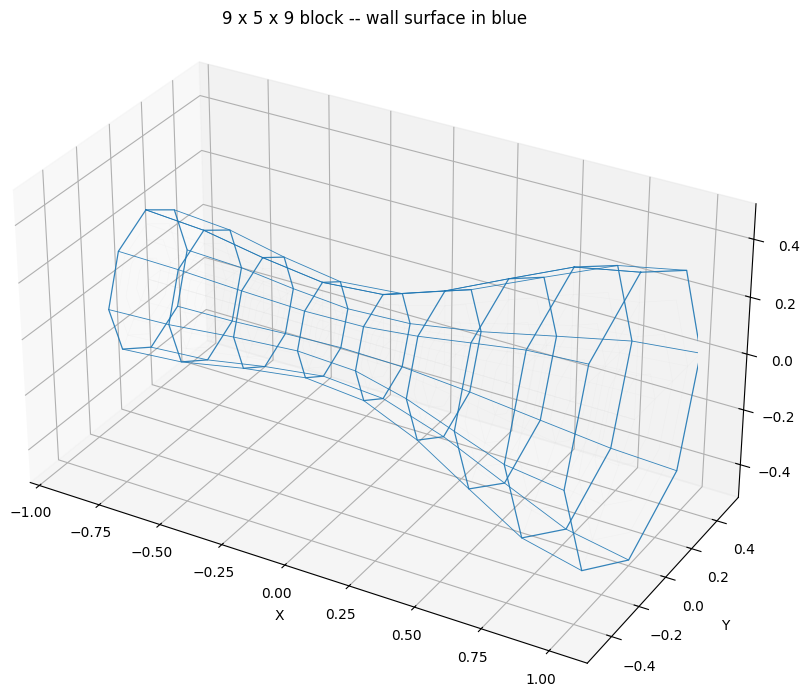

In [7]:
from duct_geometry import duct_radius
from duct_mesh import revolve_duct

x, r_wall = duct_radius(n_axial=9)
blk = revolve_duct(x, r_wall, n_radial=5, n_theta=9)
print(f"one block: ({blk.IMAX}, {blk.JMAX}, {blk.KMAX}) nodes")
plot_duct_3d(blk)


Flatten it. This particular block isn't as trivial as "one block, nothing
to match" -- it's a full 360 degree body of revolution, so its own
theta=0 and theta=360 planes coincide, and `connectivity()` finds that as
a real face match (Section 3 explains why, at production resolution).
Here, at this coarse 9x5x9 size, it's the same story on a much smaller
mesh. `fmesh.summary()` reports three counts: `Nc` cells, `Nf` faces,
`Nn` nodes -- shorthand used for the rest of this notebook:


In [8]:
face_matches, outer_faces = connectivity([blk])
print(f"face_matches: {len(face_matches)}   outer_faces: {len(outer_faces)}")

fmesh = flatten_mesh([blk], face_matches, outer_faces)
print(fmesh.summary())


0it [00:00, ?it/s]


Phase 3: Fresh-face validation...
  Phase 3 done (0 new matches)
face_matches: 1   outer_faces: 4


Calculating the volumes: 100%|██████████| 8/8 [00:00<00:00, 809.91it/s]

FlatMesh: Nc=256 Nf=864 Nn=360
  total volume = 0.478583
  total boundary surface area = 4.23608
  periodic faces = 0
  boundary faces per surface:
    id=1 (1): 32
    id=2 (2): 32
    id=3 (3): 64
    id=4 (4): 64


In [9]:
fmesh.cell_ijk

array([[0, 0, 0],
       [1, 0, 0],
       [2, 0, 0],
       [3, 0, 0],
       [4, 0, 0],
       [5, 0, 0],
       [6, 0, 0],
       [7, 0, 0],
       [0, 1, 0],
       [1, 1, 0],
       [2, 1, 0],
       [3, 1, 0],
       [4, 1, 0],
       [5, 1, 0],
       [6, 1, 0],
       [7, 1, 0],
       [0, 2, 0],
       [1, 2, 0],
       [2, 2, 0],
       [3, 2, 0],
       [4, 2, 0],
       [5, 2, 0],
       [6, 2, 0],
       [7, 2, 0],
       [0, 3, 0],
       [1, 3, 0],
       [2, 3, 0],
       [3, 3, 0],
       [4, 3, 0],
       [5, 3, 0],
       [6, 3, 0],
       [7, 3, 0],
       [0, 0, 1],
       [1, 0, 1],
       [2, 0, 1],
       [3, 0, 1],
       [4, 0, 1],
       [5, 0, 1],
       [6, 0, 1],
       [7, 0, 1],
       [0, 1, 1],
       [1, 1, 1],
       [2, 1, 1],
       [3, 1, 1],
       [4, 1, 1],
       [5, 1, 1],
       [6, 1, 1],
       [7, 1, 1],
       [0, 2, 1],
       [1, 2, 1],
       [2, 2, 1],
       [3, 2, 1],
       [4, 2, 1],
       [5, 2, 1],
       [6, 2, 1],
       [7,

`flatten_mesh` returns a `FlatMesh`: plain numpy arrays, structure-of-arrays
style -- easy to hand to any tool, no graph library required. On a mesh
this small, every field's value is checkable by hand:

- `points` `(Nn, 3)` -- node coordinates.
- `cell_volume`/`cell_centroid`/`cell_vertices` `(Nc, ...)` -- one hexahedron
  per structured `(block, i, j, k)` cell. `cell_block_id`/`cell_ijk` say
  which block and which structured index each cell came from.
- `face_owner`/`face_neighbor` `(Nf,)` -- the two cells on either side of a
  face. `face_neighbor == -1` means this face is a boundary -- right now,
  *every* face on this block's outside is `-1`, since nothing has tagged
  them yet (Section 4).
- `face_area` `(Nf, 3)` -- the face's area as a vector (length = area,
  direction = outward from `face_owner`); `face_normal`/`face_area_mag`
  are the same vector pre-split into a unit direction and a length.
- `face_centroid`/`face_vertices` -- self-explanatory.

Because the wall tapers, no single cell's volume is "the" answer the way a
rectangular box's would be -- but the block is a body of revolution, so the
*sum* of every cell's volume has to equal `integral(pi R(x)^2) dx`, the
exact volume of the solid the mesh approximates:


In [ ]:
from plot3d import analytic_volume

v_mesh = float(np.sum(fmesh.cell_volume))
v_exact = analytic_volume(x, r_wall)
print(f"mesh volume (sum of cells):  {v_mesh:.6f}")
print(f"analytic volume (pi R(x)^2 integrated over x): {v_exact:.6f}")
print(f"relative difference: {abs(v_mesh - v_exact) / v_exact:.2%}  "
      "(discretization error -- this block is deliberately coarse)")

# analytic_volume only exists because this happens to be a known body of
# revolution -- a general x, y, z mesh has no such formula. The
# geometry-agnostic check instead recomputes the block's own cell volumes
# independently, straight from its corner nodes via the divergence
# theorem, with no assumption about the mesh's shape:
v_div = float(cell_volume_divergence(blk).sum())
print(f"\nmesh volume (flatten_mesh)  : {v_mesh:.6f}")
print(f"mesh volume (divergence)    : {v_div:.6f}")
print(f"relative difference         : {abs(v_mesh - v_div) / v_div:.2e}"
      "  (bit-identical -- same formula, two independent code paths)")

c = 0
print(f"\ncell {c}: block={int(fmesh.cell_block_id[c])}, ijk={tuple(fmesh.cell_ijk[c].tolist())}")
owner_faces = np.nonzero(fmesh.face_owner == c)[0]
print(f"  faces where this cell is the owner: {owner_faces.tolist()}")
print(f"  their neighbors: {fmesh.face_neighbor[owner_faces].tolist()}  (-1 = boundary, this cell is a corner cell)")

## 3. The production duct mesh

Same duct as Section 2 -- the Bezier wall `R(x)` revolved about the
x-axis -- but now at the resolution Section 5 actually solves it at:
201 x 25 x 37, not the coarse 9x5x9 block kept small enough to check by
hand. No foreign dataset, no download: everything below is built from
[`examples/converge_diverge_duct`](https://github.com/nasa/Plot3D_utilities/tree/main/examples/converge_diverge_duct),
the same files Section 5 runs.


axial stations : 201  from x=-0.900 to x=1.000
throat         : x=-0.1400  r=0.1666  (index 80)
inlet  A/At    : 2.252
exit   A/At    : 9.007


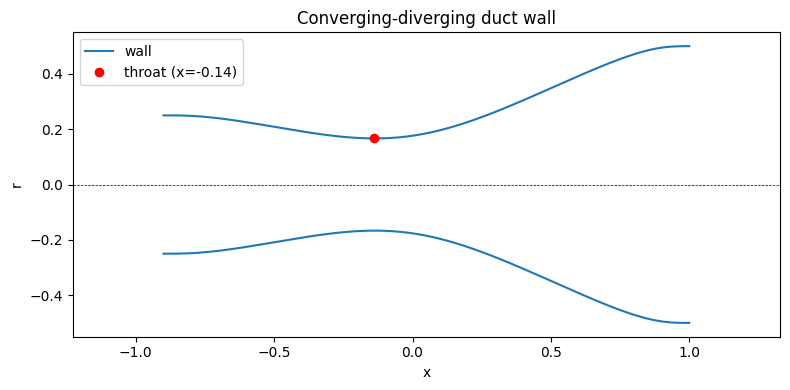

In [11]:
from duct_geometry import area_ratio, throat

x, r_wall = duct_radius(n_axial=201)
i_t, x_t, r_t = throat(x, r_wall)
ar = area_ratio(r_wall)

print(f"axial stations : {x.size}  from x={x[0]:.3f} to x={x[-1]:.3f}")
print(f"throat         : x={x_t:.4f}  r={r_t:.4f}  (index {i_t})")
print(f"inlet  A/At    : {ar[0]:.3f}")
print(f"exit   A/At    : {ar[-1]:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(x, r_wall, "C0", label="wall")
plt.plot(x, -r_wall, "C0")
plt.plot([x_t], [r_t], "ro", label=f"throat (x={x_t:.2f})")
plt.axhline(0.0, color="k", lw=0.5, ls="--")
plt.xlabel("x")
plt.ylabel("r")
plt.title("Converging-diverging duct wall")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()


Converges to a throat, then diverges -- that shape is why Section 5's
flow chokes there and forms a normal shock downstream. Nothing here knows
about meshes yet; the block comes next, at this same resolution.


block shape     : 201 x 25 x 37
nodes           : 185925
wall cell       : 0.543% of local R
axis cell       : 13.516% of local R
clustering ratio: 24.9 : 1


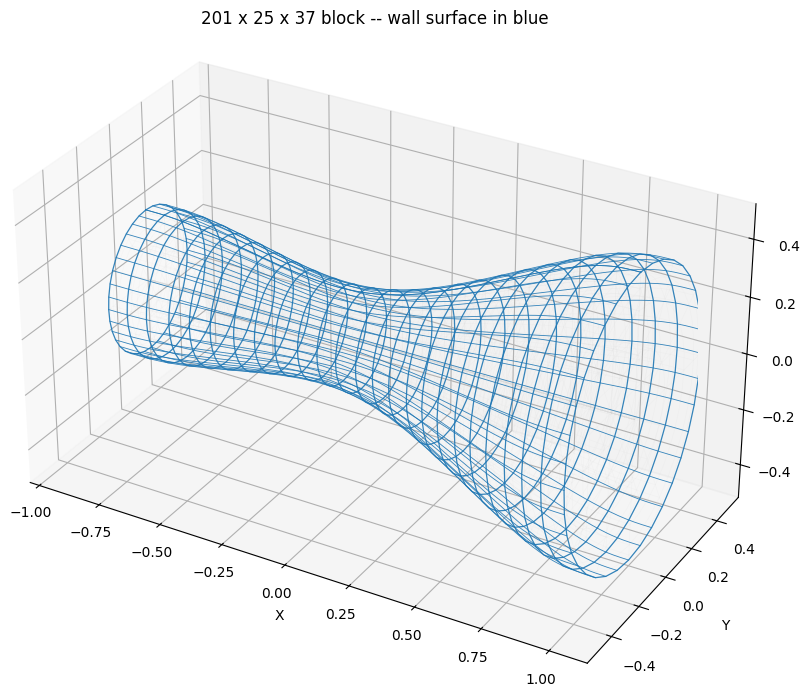

In [12]:
from duct_mesh import inflation_report

blk_prod = revolve_duct(x, r_wall, n_radial=25, n_theta=37)
wall_frac, axis_frac, cluster = inflation_report(n_radial=25)

print(f"block shape     : {blk_prod.IMAX} x {blk_prod.JMAX} x {blk_prod.KMAX}")
print(f"nodes           : {blk_prod.X.size}")
print(f"wall cell       : {100 * wall_frac:.3f}% of local R")
print(f"axis cell       : {100 * axis_frac:.3f}% of local R")
print(f"clustering ratio: {cluster:.1f} : 1")

plot_duct_3d(blk_prod)


Full 360 degrees, not a wedge: the first and last theta planes sit at the
same physical location, closing the mesh into a real body of revolution.
That closure is exactly what the connectivity check below finds as a face
match. Radial spacing is a geometric inflation layer clustered at the
wall, the way a real viscous mesh is built -- barely visible in 3D at
this size, clearer in the flattened 2D view next.


axisymmetry error: 1.110e-16  (every theta plane agrees to round-off)
3D nodes: 185925   2D nodes: 5025   (37.0x fewer)


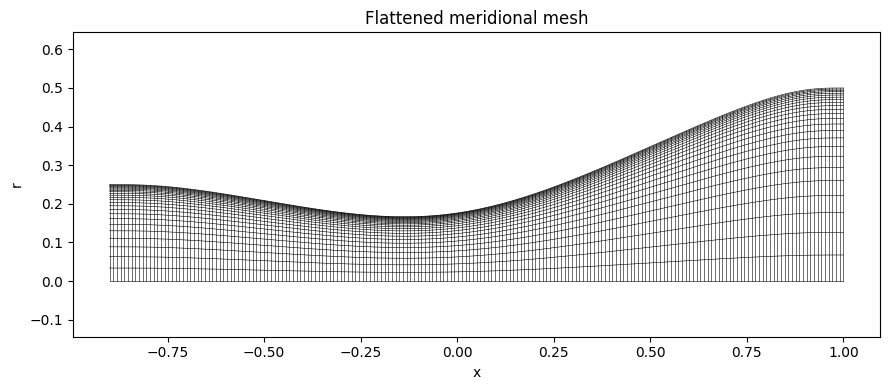

In [13]:
from plot3d import axisymmetry_error, flatten_to_meridional, node_count_reduction

print(f"axisymmetry error: {axisymmetry_error(blk_prod):.3e}  (every theta plane agrees to round-off)")

n3, n2, factor = node_count_reduction(blk_prod)
print(f"3D nodes: {n3}   2D nodes: {n2}   ({factor:.1f}x fewer)")

x2d, r2d = flatten_to_meridional(blk_prod)
plt.figure(figsize=(9, 4))
plt.plot(x2d, r2d, "k-", lw=0.4)
plt.plot(x2d.T, r2d.T, "k-", lw=0.4)
plt.xlabel("x")
plt.ylabel("r")
plt.title("Flattened meridional mesh")
plt.axis("equal")
plt.tight_layout()
plt.show()


That 37x is a *different* kind of "flatten" than `flatten_mesh` --
collapsing redundant theta planes because the physics is axisymmetric,
not building the owner/neighbor graph. Section 5's solver runs on this 2D
grid directly. `flatten_mesh` next works on the full 3D block(s) instead,
the way a general (non-axisymmetric) solver would actually read it.

We use `plot3d.connectivity.connectivity`, **not** `connectivity_fast`,
as the default habit for graph export -- even though `connectivity_fast`
happens to be exact here. `connectivity_fast` reduces every block by
`min(gcd(IMAX-1, JMAX-1, KMAX-1))` **taken across all blocks**, then
strides every block by that one shared factor. If every block's own GCD
already equals that shared factor, the reduction divides each block's
dimensions exactly and nothing is lost. The failure mode is a mesh with
blocks of *different* native GCDs: the shared minimum then doesn't evenly
divide the coarser block's own dimensions, and `X[::factor]` silently
drops its last row of nodes -- which can crop away the exact face that
should have matched its neighbor (this is what happened on a real stator
mesh, dropping half its real face matches and mis-tagging them as
boundaries). A missed match becomes a phantom wall the solver wrongly
treats as solid. Since graph export code doesn't know in advance whether
a mesh's blocks share a GCD, `connectivity()` is the safe default;
`connectivity_fast` is worth reaching for only once you've checked that
condition holds.

Sections 1-2 both had a reason to stay simple: one had nothing to match by
construction, the other used a single block whose only face match was
against *itself* (the theta=0/theta=360 seam a full revolve always
creates). Neither actually exercised `flatten_mesh`'s real reason to
exist -- **more than one block**. So split this same production mesh down
the middle, into two blocks that share a real interior interface:

In [ ]:
mid = blk_prod.IMAX // 2
b0 = Block(np.ascontiguousarray(blk_prod.X[:mid + 1]),
           np.ascontiguousarray(blk_prod.Y[:mid + 1]),
           np.ascontiguousarray(blk_prod.Z[:mid + 1]))
b1 = Block(np.ascontiguousarray(blk_prod.X[mid:]),
           np.ascontiguousarray(blk_prod.Y[mid:]),
           np.ascontiguousarray(blk_prod.Z[mid:]))
blocks = [b0, b1]
print(f"block 0: {b0.IMAX} x {b0.JMAX} x {b0.KMAX}")
print(f"block 1: {b1.IMAX} x {b1.JMAX} x {b1.KMAX}")

face_matches, outer_faces = connectivity(blocks)
print(f"\nface_matches: {len(face_matches)}   outer_faces: {len(outer_faces)}")

Three matches, not one: the real cross-block interface at the split
(block 0's `I=IMAX` against block 1's `I=1`), plus each half's *own*
theta seam -- splitting the block didn't remove Section 3's self-match,
it just gave each half its own copy of it. `flatten_mesh` treats all
three exactly the same way: an edge between two graph nodes, whether
"the other side" is a different block or the same block found again by
coincident geometry.

In [ ]:
fmesh = flatten_mesh(blocks, face_matches, outer_faces)
print(fmesh.summary())

total_block_nodes = b0.X.size + b1.X.size
welded = total_block_nodes - fmesh.points.shape[0]
print(f"\n{total_block_nodes} block nodes (2 blocks) -> {fmesh.points.shape[0]} graph nodes "
      f"({welded} welded away: the cross-block interface, once, "
      "plus each block's own theta seam)")

v_mesh = float(np.sum(fmesh.cell_volume))
v_exact = analytic_volume(x, r_wall)
print(f"\nmesh volume (2 blocks): {v_mesh:.6f}")
print(f"analytic volume       : {v_exact:.6f}  (this duct's known R(x) profile)")
print(f"relative difference   : {abs(v_mesh - v_exact) / v_exact:.2%}")
print("(matches Section 2's single-block check almost exactly -- splitting"
      " a mesh into blocks changes none of the physics.)")

# A general x, y, z mesh has no such analytic profile to check against.
# The geometry-agnostic alternative recomputes each block's own cell
# volumes independently, straight from its corner nodes via the
# divergence theorem, with no assumption about the mesh's shape:
v_div = sum(float(cell_volume_divergence(b).sum()) for b in blocks)
print(f"\nmesh volume (flatten_mesh)         : {v_mesh:.6f}")
print(f"mesh volume (per-block divergence) : {v_div:.6f}")
print(f"relative difference                : {abs(v_mesh - v_div) / v_div:.2e}"
      "  (bit-identical -- same formula, independently applied per block)")

### Tagging the boundaries

The 6 remaining outer faces are real boundaries -- inlet and outlet (one
each, now on different blocks), plus axis and wall, split in half between
the two blocks. `tag_surfaces_geometric` tags by position: closest to -x
-> inlet, +x -> outlet, min-radius -> hub, max-radius -> shroud, else ->
blade. Run it bare first:

In [ ]:
outer_faces_geo, surface_ids_geo = tag_surfaces_geometric(blocks, outer_faces, axis="x")
print("surface_ids:", surface_ids_geo)
for f in outer_faces_geo:
    name = surface_ids_geo[str(f["id"])]
    print(f"  block {f['block_index']}  lb={f['lb']}  ub={f['ub']}  -> id={f['id']} ({name})")

Same failure mode this section's single-block version had, now visible on
exactly one of the two wall halves: block 0's wall face (the converging, upstream
half) lands too far from the true max radius for the heuristic's default
`band`, and gets mis-tagged `blade`; block 1's wall face (the diverging,
downstream half) happens to land close enough and tags correctly.
Splitting the mesh didn't introduce this mistake, it just makes plain
that it's per-face, not "wrong for this whole mesh." `overrides` fixes
each mistagged `(block, side)` pair explicitly -- here, every side on
both blocks, since a real deck build would rather be explicit about every
boundary than trust the heuristic silently:

In [ ]:
overrides = {
    (0, 0): 1,  # block 0, I=1    -> inlet
    (1, 1): 2,  # block 1, I=IMAX -> outlet
    (0, 2): 4,  # block 0, J=1    -> axis
    (1, 2): 4,  # block 1, J=1    -> axis
    (0, 3): 5,  # block 0, J=JMAX -> wall
    (1, 3): 5,  # block 1, J=JMAX -> wall
}
outer_faces, _ = tag_surfaces_geometric(blocks, outer_faces, axis="x", overrides=overrides)
surface_ids = {1: "inlet", 2: "outlet", 4: "axis", 5: "wall"}

for f in outer_faces:
    print(f"  block {f['block_index']}  -> id={f['id']} ({surface_ids[f['id']]})")

## 4. Exporting to simulation

Every boundary is tagged now. Attach physics and see what the graph
actually looks like once it's built.


### Which node is a wall? Which is fluid?

Every node in the flattened graph carries a `point_bc_type`: wall, inlet,
outlet, or interior (fluid) -- no `periodic` type here, since this mesh's
interior seams all came from `face_matches`, not rotational periodicity.
The axis is declared a wall on purpose:
`examples/converge_diverge_duct`'s own solver reuses the exact same
reflective ghost-cell formula (`euler_bc.reflect_ghost`) for both the
outer wall and the centerline -- the axis's face area is proportional to
`r`, exactly zero there, so tagging it a wall is belt-and-braces, not a
simplification.


In [ ]:
bcs = [
    Plot3DFlattenInletBC(name="inlet", surfaces=[1], total_pressure=2.0e5, total_temperature=500.0),
    Plot3DFlattenOutletBC(name="outlet", surfaces=[2], back_pressure=1.0e5),
    Plot3DFlattenWallBC(name="axis", surfaces=[4], thermal="adiabatic"),
    Plot3DFlattenWallBC(name="wall", surfaces=[5], thermal="adiabatic"),
]

fmesh = flatten_mesh(
    blocks, face_matches, outer_faces,
    surface_ids=surface_ids, bcs=bcs,
)
print(fmesh.summary())


`P0`/`T0`/`p_back` are the exact numbers `examples/converge_diverge_duct`
solves with (`euler_solver_flatten.Config`'s defaults) -- Section 5 runs
this same physics. This is the picture that actually answers "which node
is a wall, which is fluid" -- not the YAML file below. Color every
non-fluid node by its type:


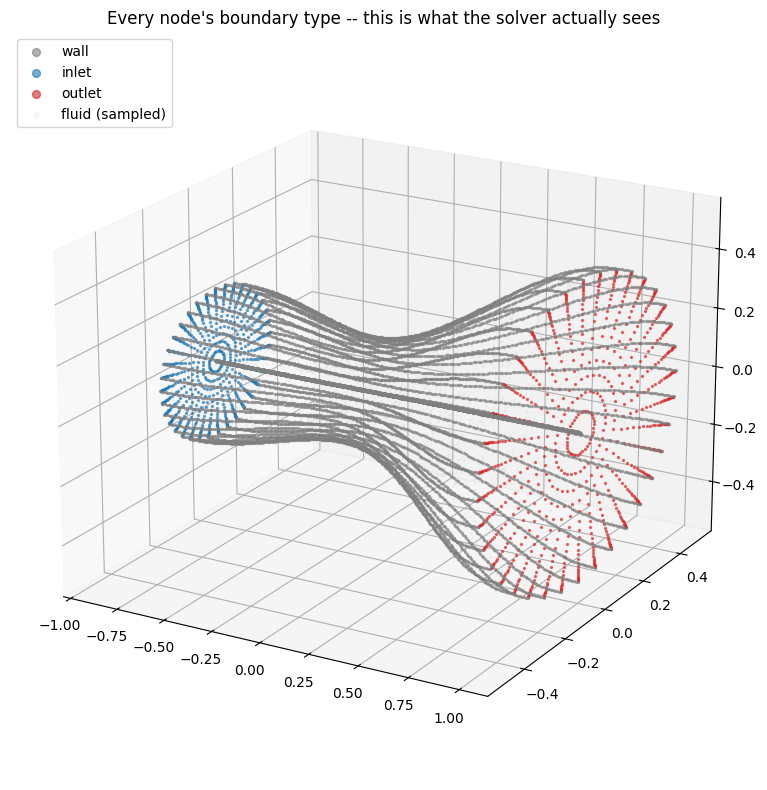

In [19]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {"wall": "tab:gray", "inlet": "tab:blue", "outlet": "tab:red"}
rng = np.random.default_rng(0)

for bc_code, name in fmesh.bc_type_legend.items():
    if name == "interior":
        continue
    idx = np.nonzero(fmesh.point_bc_type == bc_code)[0]
    if len(idx) == 0:
        continue
    pts = fmesh.points[idx]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2, color=colors.get(name, "black"),
              label=name, alpha=0.6, depthshade=False)

interior_code = [c for c, n in fmesh.bc_type_legend.items() if n == "interior"][0]
interior_idx = np.nonzero(fmesh.point_bc_type == interior_code)[0]
sample = rng.choice(interior_idx, size=min(3000, len(interior_idx)), replace=False)
pts = fmesh.points[sample]
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1, color="lightgray", alpha=0.15,
          label="fluid (sampled)", depthshade=False)

ax.set_title("Every node's boundary type -- this is what the solver actually sees")
ax.legend(loc="upper left", markerscale=4)
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()


Both rings of gray points are `wall` -- the outer duct wall and the
centerline axis are visually indistinguishable here, because the solver
treats them identically.

### Writing what a solver reads

The physics -- pressure, temperature, wall type -- goes in a
`boundary_conditions:` YAML fragment. Only the fields you actually set
are written:


In [20]:
bc_yaml_path = os.path.join(OUT_DIR, "duct_boundary_conditions.yaml")
yaml_text = write_boundary_conditions_yaml(bcs, bc_yaml_path)
print(yaml_text)


boundary_conditions:
- name: inlet
  type: inlet
  surfaces: [1]
  total_pressure: 200000.0
  total_temperature: 500.0
- name: outlet
  type: outlet
  surfaces: [2]
  back_pressure: 100000.0
- name: axis
  type: wall
  surfaces: [4]
  thermal: adiabatic
- name: wall
  type: wall
  surfaces: [5]
  thermal: adiabatic



A run deck ties it together: `mesh:` points at the grid, `boundary_conditions:`
is the YAML fragment above, pasted straight in:

```yaml
mesh:
  grid_file: "duct_3d.xyz"
  connectivity_file: "duct_3d.connectivity.json"
  format: formatted

boundary_conditions:
  - name: inlet
    type: inlet
    surfaces: [1]
    total_pressure: 200000.0
    total_temperature: 500.0
  - name: outlet
    type: outlet
    surfaces: [2]
    back_pressure: 100000.0
```

At load time, the solver reads the grid and (block-level) connectivity,
**builds its own internal per-cell graph** from those two pieces -- the
same graph this notebook built directly with `flatten_mesh` -- then
applies each `boundary_conditions:` entry to every cell face whose
surface `id` matches. Nothing here is solver-specific; the graph is the
same either way.

One honest caveat: `examples/converge_diverge_duct` itself doesn't read
this YAML -- its solver takes these same numbers straight from the
`Config` dataclass in `euler_solver_flatten.py`. The fragment above shows
the deck format and matches Section 5's actual physics; it isn't wired
into that example's own run.


## 5. Solving it: the converging-diverging duct

Section 2's duct wall and revolved block were the coarse, hand-checkable
stand-ins. Full-resolution, the same geometry chokes at the throat and
forms a normal shock -- run here straight from the same
[`examples/converge_diverge_duct`](https://github.com/nasa/Plot3D_utilities/tree/main/examples/converge_diverge_duct)
already on `sys.path`: revolve, flatten (as Section 2 did), then solve the
axisymmetric Euler equations on the flattened mesh with JAX, checked
against the analytic quasi-1D solution.

`main.py` runs every stage and draws four figures inline; see that
folder's `README.md` for the full write-up (physics, numerics, and how to
read the figures).



STAGE 0 - solver sanity check
Uniform flow in a straight pipe is an exact solution, so its
residual must be machine zero.  This one check exercises the
axisymmetric source term, every face normal, and the wall reflection.
  max |residual| / flux scale : 2.454e-16

STAGE 1 - geometry
  axial stations   : 201   x = [-0.90, 1.00]
  throat           : x = -0.1400, r = 0.1666
  inlet  A/A_throat: 2.252
  exit   A/A_throat: 9.007
  max wall angle   : 23.9 deg (diverging section - remember this for the summary)

1D ISENTROPIC PREDICTION - from A(x)/A* alone, before any CFD
  Once the throat is sonic, A* = A_throat and the area-Mach relation
  A/A* = f(M) fixes M at every station from R(x).  The two isentropic
  branches at the exit bound the back pressure and decide the regime:
  exit A/A*                 : 9.007
  subsonic branch at exit   : M = 0.0644, p =   199.4 kPa  (unchoked limit)
  supersonic branch at exit : M = 3.8069, p =     1.7 kPa  (shock-free limit)
  normal shock at the exit 

Reading binary blocks: 100%|██████████| 1/1 [00:00<00:00, 121.40block/s]

  round tripped through duct_3d.xyz

STAGE 3 - flatten to the meridional plane
  axisymmetry error: 1.110e-16  (round-off)
  3D nodes         : 185925
  2D nodes         : 5025
  reduction        : 37x fewer nodes, same information
  duct volume      : 0.536114 (analytic 0.536124)
  drawing Figures 1 and 2 (domain, ghost cells)...


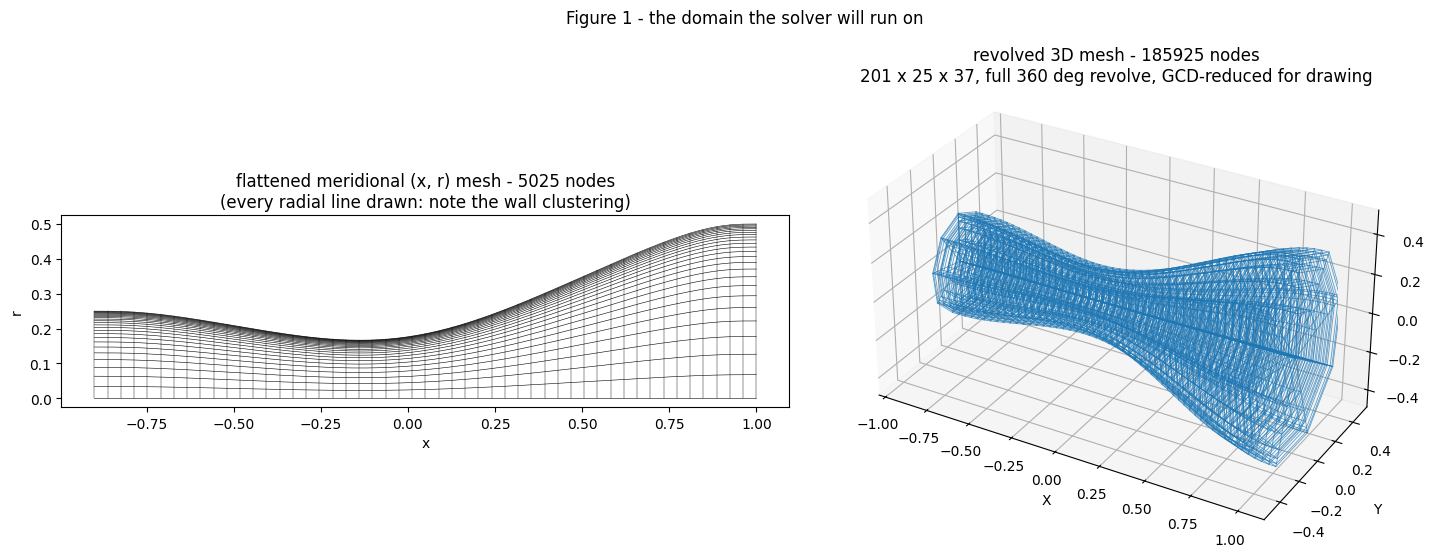

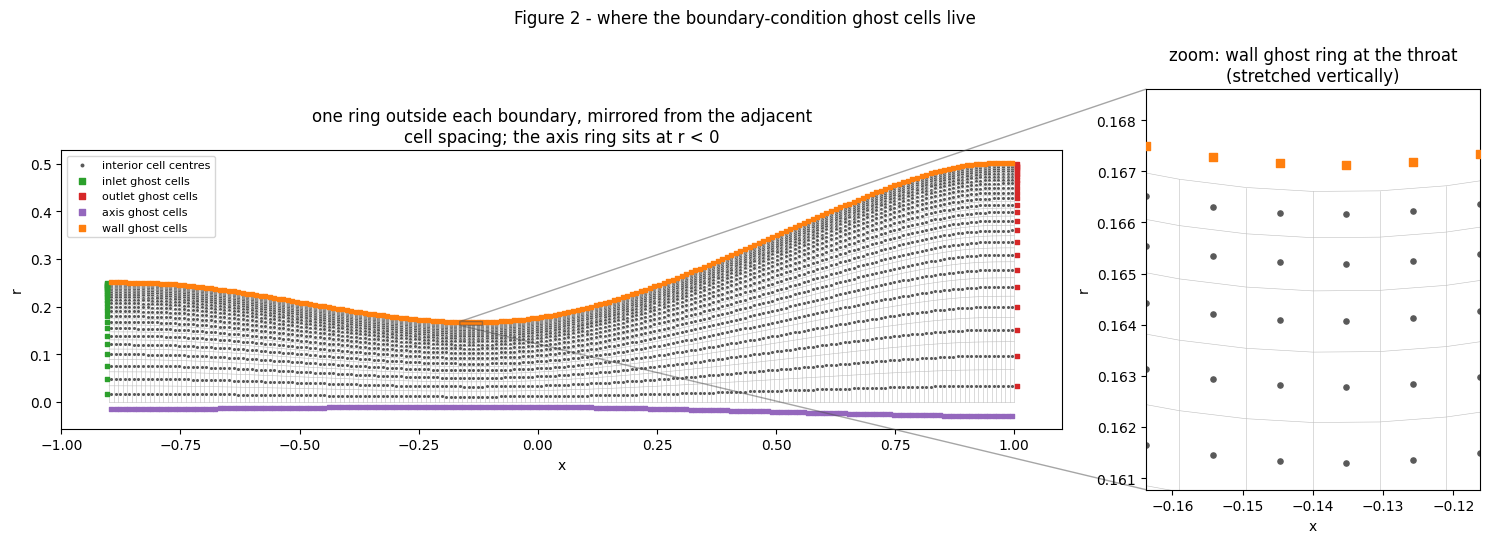


STAGE 4 - axisymmetric Euler solve (JAX, vectorized)
  cells            : 200 x 24 = 4800
  inlet            : P0 = 2.000e+05 Pa, T0 = 500.0 K
  outlet           : p  = 1.000e+05 Pa
  CFL              : 1.5
  marching...
    iter      1   residual 1.000e+00
    iter    500   residual 4.750e-02
    iter   1000   residual 8.656e-03
    iter   1500   residual 1.910e-03
    iter   2000   residual 9.360e-04
    iter   2500   residual 3.599e-04
    iter   3000   residual 1.548e-04
    iter   3500   residual 6.111e-05
    iter   4000   residual 2.447e-05
    iter   4500   residual 9.439e-06
    iter   5000   residual 3.615e-06
    iter   5500   residual 1.349e-06
    iter   6000   residual 4.957e-07
  iterations       : 6000
  final residual   : 4.957e-07
  wall clock       : 26.58 s (4.43 ms/iteration)
  (the residual plateaus once the shock stops moving to within a cell - that is normal for a first-order shock-capturing scheme)

STAGE 5 - vectorized (JAX) vs nested Python loops
  Same equa

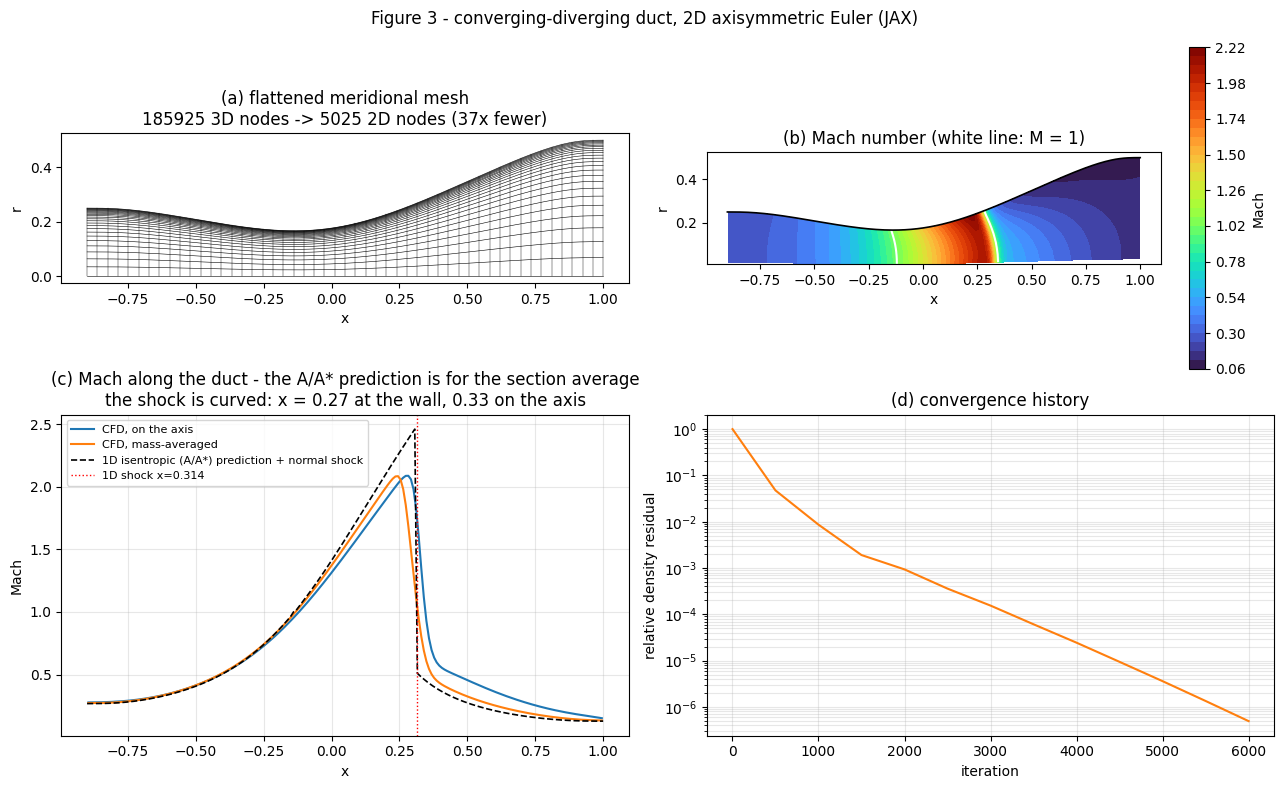

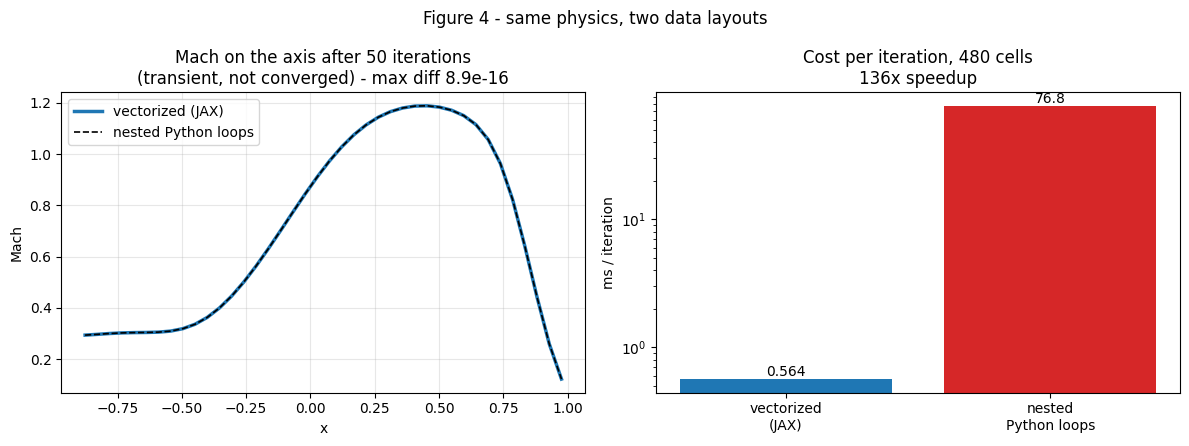

<Figure size 640x480 with 0 Axes>

In [21]:
%run Plot3D_utilities/examples/converge_diverge_duct/main.py

## 6. Why flatten? Three ways to run the same duct

`examples/converge_diverge_duct/README.md` reports the vectorized JAX
solver as roughly 200x faster per iteration than the same physics written
as nested Python loops. Reproduce that live, three ways, on the same
coarse comparison mesh `main.py` itself uses
(`C_AXIAL, C_RADIAL, C_THETA = 41, 13, 7`, 50 iterations) so the numbers
below are directly comparable to the README's:

- **A** -- the plain Plot3D block, solved with nested Python loops
  (`euler_solver_block.solve`) -- no flattening, no vectorization.
- **B** -- the flattened mesh, solved with JAX (`euler_solver_flatten.solve`),
  on whatever device JAX finds.
- **C** -- the same flattened-mesh JAX solve, forced onto CPU, so B and C
  only differ if a GPU is actually involved.

50 iterations is a transient, not a converged flow field -- this compares
software and hardware cost, not physics.


In [22]:
import time

import jax

from euler_metrics import to_jax
from euler_physics import mach
from euler_solver_block import solve as solve_block
from euler_solver_flatten import Config, initial_condition, solve as solve_flatten
from main import build_pipeline

print("jax default backend:", jax.default_backend())
print("jax devices:", jax.devices())

cfg = Config(p0=2.0e5, t0=500.0, p_back=1.0e5)
_, _, _, _, _, cmetrics_np = build_pipeline(41, 13, 7)
cmetrics = to_jax(cmetrics_np)
U0 = initial_condition(cmetrics, cfg)
U0_np = np.asarray(U0)

print(f"\ncells: {cmetrics_np.vol.size}   iterations: 50")


jax default backend: cpu
jax devices: [CpuDevice(id=0)]

cells: 480   iterations: 50


### A) plain Plot3D block, nested Python loops


In [23]:
t0 = time.perf_counter()
U_loop, _ = solve_block(cmetrics_np, cfg, n_iter=50, tol=0.0, report_every=50, U0=U0_np)
t_loop = time.perf_counter() - t0
ms_loop = 1000.0 * t_loop / 50
print(f"A) plain Plot3D block (nested loops): {ms_loop:8.3f} ms/iteration")


A) plain Plot3D block (nested loops):   77.785 ms/iteration


### B) flattened mesh, JAX, device-native

Whatever device JAX finds -- a GPU, if this runtime has one attached.
The first call includes a one-time trace/compile; time that separately
from the steady-state cost:


In [24]:
t_compile = time.perf_counter()
solve_flatten(cmetrics, cfg, n_iter=1, tol=0.0, report_every=1, U0=U0)
t_compile = time.perf_counter() - t_compile

t0 = time.perf_counter()
U_jax, _ = solve_flatten(cmetrics, cfg, n_iter=50, tol=0.0, report_every=50, U0=U0)
U_jax.block_until_ready()
t_jax = time.perf_counter() - t0
ms_jax = 1000.0 * t_jax / 50

print(f"B) flattened mesh + JAX on {jax.default_backend()}:")
print(f"   one-time compile: {1000 * t_compile:8.1f} ms")
print(f"   steady state    : {ms_jax:8.3f} ms/iteration")


B) flattened mesh + JAX on cpu:
   one-time compile:      3.9 ms
   steady state    :    0.566 ms/iteration


### C) flattened mesh, JAX, forced onto CPU

`Metrics` and the solve state are `NamedTuple`s, so they're already valid
JAX pytrees -- `jax.device_put` moves the whole struct in one call, no
custom code needed:


In [25]:
cpu = jax.devices("cpu")[0]
cmetrics_cpu = jax.device_put(cmetrics, cpu)
U0_cpu = jax.device_put(U0, cpu)

t_compile_cpu = time.perf_counter()
solve_flatten(cmetrics_cpu, cfg, n_iter=1, tol=0.0, report_every=1, U0=U0_cpu)
t_compile_cpu = time.perf_counter() - t_compile_cpu

t0 = time.perf_counter()
U_cpu, _ = solve_flatten(cmetrics_cpu, cfg, n_iter=50, tol=0.0, report_every=50, U0=U0_cpu)
U_cpu.block_until_ready()
t_cpu = time.perf_counter() - t0
ms_cpu = 1000.0 * t_cpu / 50

print(f"C) flattened mesh + JAX forced onto {cpu}:")
print(f"   one-time compile: {1000 * t_compile_cpu:8.1f} ms")
print(f"   steady state    : {ms_cpu:8.3f} ms/iteration")


C) flattened mesh + JAX forced onto cpu:0:
   one-time compile:   1989.9 ms
   steady state    :    0.562 ms/iteration


### Bringing it together

Same equations, same mesh, same initial state -- confirm all three agree
to round-off before trusting any speedup number:


max |M_A - M_B| : 8.882e-16
max |M_A - M_C| : 8.882e-16
max |M_B - M_C| : 0.000e+00
-> identical to round-off: all three solved the same problem.

method                            ms/iteration  speedup vs A
A) block, nested loops                  77.785          1.0x
B) flattened, JAX (cpu)                  0.566        137.4x
C) flattened, JAX (cpu)                  0.562        138.4x


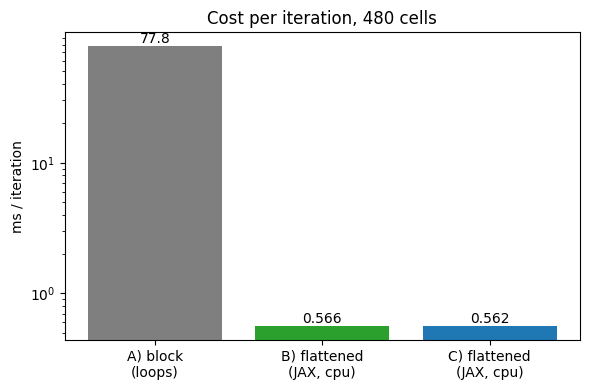

In [26]:
M_loop = np.asarray(mach(U_loop))
M_jax = np.asarray(mach(U_jax))
M_cpu = np.asarray(mach(U_cpu))

print(f"max |M_A - M_B| : {np.max(np.abs(M_loop - M_jax)):.3e}")
print(f"max |M_A - M_C| : {np.max(np.abs(M_loop - M_cpu)):.3e}")
print(f"max |M_B - M_C| : {np.max(np.abs(M_jax - M_cpu)):.3e}")
print("-> identical to round-off: all three solved the same problem.\n")

print(f"{'method':32s}{'ms/iteration':>14s}{'speedup vs A':>14s}")
print(f"{'A) block, nested loops':32s}{ms_loop:14.3f}{'1.0x':>14s}")
print(f"{'B) flattened, JAX (' + jax.default_backend() + ')':32s}{ms_jax:14.3f}{ms_loop / ms_jax:13.1f}x")
print(f"{'C) flattened, JAX (cpu)':32s}{ms_cpu:14.3f}{ms_loop / ms_cpu:13.1f}x")

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["A) block\n(loops)", f"B) flattened\n(JAX, {jax.default_backend()})", "C) flattened\n(JAX, cpu)"]
values = [ms_loop, ms_jax, ms_cpu]
bars = ax.bar(labels, values, color=["tab:gray", "tab:green", "tab:blue"])
ax.set_yscale("log")
ax.set_ylabel("ms / iteration")
ax.set_title(f"Cost per iteration, {cmetrics_np.vol.size} cells")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3g}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


If B and C just reported the same backend and near-identical timings,
that's the correct result, not a bug -- it means no GPU is attached to
this runtime, so "device-native" and "forced CPU" are the same thing.
On a Colab GPU runtime, B's number would drop further below C's: C
isolates what flattening and vectorization alone buy (A -> C), and B on
top of that isolates what the GPU buys (C -> B).


## Cleanup

In [ ]:
import shutil

if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
